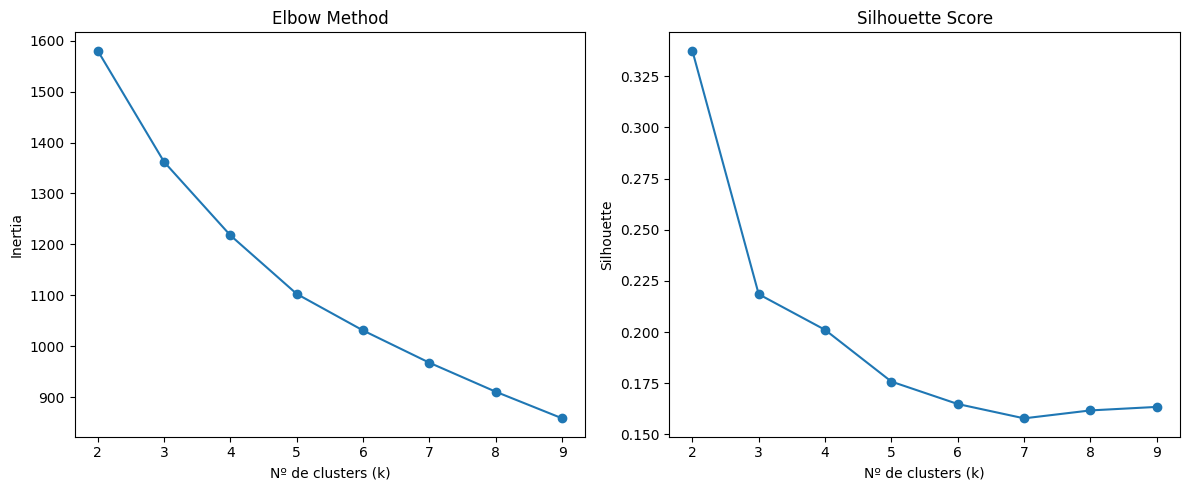


Número ideal de clusters encontrado: 4

   cluster  exercise_mean  social_mean  sleep_index_mean  stress_mean  \
0        0      93.323699     6.158960          7.300116     9.635838   
1        1     142.849462     5.072043         12.336774     6.938710   
2        2     115.090909    10.927273         20.716818     4.165909   
3        3     105.483146    12.853933          8.182135     8.478652   

   productivity_mean  screen_time_mean  wellness_mean  count  
0           4.306358         10.882543       0.600578    173  
1           6.254839          7.709785       3.229032     93  
2           8.327273          6.018409       6.138636     44  
3           5.348315          8.160562       1.550562     89  


C:\Users\ljvie\AppData\Local\Temp\ipykernel_36172\193019857.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="mental_wellness_index_0_10", palette="Set2")


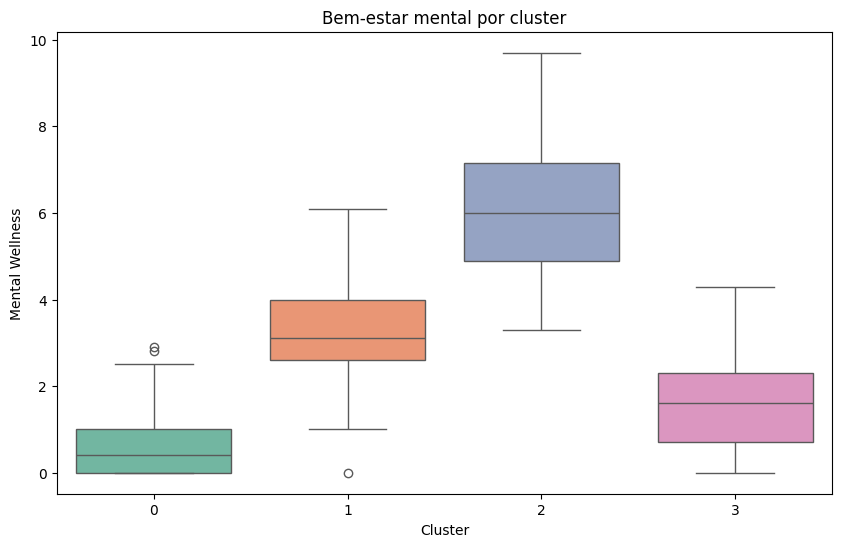

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# ===============================
# 1. LER E PREPARAR OS DADOS
# ===============================

db_path = r"C:/Users/ljvie/OneDrive/Desktop/Mestrado/Aprendizagem Automática/mental_health.db"
main_table = "dados"

conn = sqlite3.connect(db_path)

# ler tabela
df = pd.read_sql_query(f"SELECT * FROM {main_table};", conn)

conn.close()

# remover colunas Unnamed
for c in list(df.columns):
    if str(c).startswith("Unnamed"):
        df = df.drop(columns=[c])

# criar sleep_index = sleep_hours * sleep_quality
df["sleep_index"] = df["sleep_hours"] * df["sleep_quality_1_5"]

# Features para clustering
features = [
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "sleep_index",
    "stress_level_0_10",
    "productivity_0_10",
    "screen_time_hours"
]

X = df[features].copy()

# ===============================
# 2. NORMALIZAÇÃO
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 3. ESCOLHER O NÚMERO IDEAL DE CLUSTERS
# ===============================

inertias = []
silhouettes = []

K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot Elbow + Silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Nº de clusters (k)")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K, silhouettes, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Nº de clusters (k)")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

# ===============================
# 4. APLICAR CLUSTERING FINAL
# ===============================

k_final = silhouettes.index(max(silhouettes)) + 4   

kmeans = KMeans(n_clusters=k_final, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"\nNúmero ideal de clusters encontrado: {k_final}\n")

# ===============================
# 5. ANÁLISE DOS CLUSTERS
# ===============================

cluster_summary = df.groupby("cluster").agg(
    exercise_mean=("exercise_minutes_per_week", "mean"),
    social_mean=("social_hours_per_week", "mean"),
    sleep_index_mean=("sleep_index", "mean"),
    stress_mean=("stress_level_0_10", "mean"),
    productivity_mean=("productivity_0_10", "mean"),
    screen_time_mean=("screen_time_hours", "mean"),
    wellness_mean=("mental_wellness_index_0_10", "mean"),
    count=("cluster", "size")
).reset_index()

print(cluster_summary)

# ===============================
# 6. VISUALIZAÇÃO
# ===============================

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="cluster", y="mental_wellness_index_0_10", palette="Set2")
plt.title("Bem-estar mental por cluster")
plt.xlabel("Cluster")
plt.ylabel("Mental Wellness")
plt.show()
